# 5a — Data Preparation for Machine Learning

## What This Notebook Does
This notebook prepares the dataset for machine learning (Phase 4).
It feeds directly into `5b_model_training.ipynb` and `5c_model_analysis.ipynb`.

### Steps
1. Install libraries and import packages
2. Download the US Accidents dataset from Kaggle
3. Load and sample 500K rows (identical to Phase 2)
4. Preprocess — same pipeline as `0_full_analysis.ipynb`
5. Enrich with US Census population data (same as `4_external_data_enrichment.ipynb`)
6. Enrich with NOAA Climate Normals (same as `4_external_data_enrichment.ipynb`)
7. Visualize target variable and check class imbalance
8. Engineer and encode all features
9. Compute majority class baseline (Week 8 lecture)
10. Split into train/test sets and apply StandardScaler (Week 8 & 9 lectures)
11. Save all arrays to disk for Notebooks B and C

In [2]:
# Install required packages
# kaggle       → download the US Accidents dataset from Kaggle
# scikit-learn → all ML models and preprocessing tools (Week 8, 9, 10)
# statsmodels  → kept for consistency with Phase 2
!pip install kaggle statsmodels scikit-learn -q
print("Libraries installed!")

Libraries installed!


## Import Libraries

In [3]:
import os
import json
import joblib
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# Model selection and preprocessing: Hold-out method, Stratified Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# Plot
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Output folders
os.makedirs("figures/ml", exist_ok=True)
os.makedirs("ml_data", exist_ok=True)

print("All imports successful!")

All imports successful!


## Download Dataset

Same Kaggle download as Phase 2 (`0_full_analysis.ipynb`).
If `US_Accidents_March23.csv` already exists in the Colab runtime, download is skipped.

In [4]:
kaggle_creds = {
    "username": "zeynep.altundal",
    "key":      "KGAT_ae2c80c982f032b1ba26f677808251bd"
}
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json


if not os.path.exists("US_Accidents_March23.csv"):
    !kaggle datasets download -d sobhanmoosavi/us-accidents -q
    !unzip -q us-accidents.zip
    print("Dataset downloaded and unzipped!")
else:
    print("Dataset already exists — skipping download.")

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
Dataset downloaded and unzipped!


## Load Dataset

Identical to Phase 2:
- Full CSV loaded (~7.7 million rows, 46 features)
- 500,000 rows sampled with `random_state=42`
- Same sample used consistently across all phases

In [5]:
print("Loading dataset... (may take ~1 minute)")
df_full = pd.read_csv("US_Accidents_March23.csv", low_memory=False)
print(f"Full dataset shape   : {df_full.shape}")

# Same sample as Phase 2 — 500K rows, random_state=42 for reproducibility
df = df_full.sample(n=500_000, random_state=42).copy()
del df_full

print(f"Working sample shape : {df.shape}")
df.head(3)

Loading dataset... (may take ~1 minute)
Full dataset shape   : (7728394, 46)
Working sample shape : (500000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7133276,A-7182628,Source1,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,26.706900,-80.119360,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
5363845,A-5404588,Source1,2,2022-04-21 10:01:00.000000000,2022-04-21 11:44:08.000000000,38.781024,-121.265820,38.780377,-121.265815,0.045,...,False,False,True,False,False,False,Day,Day,Day,Day
155993,A-156000,Source3,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day


## Preprocessing

**Identical pipeline to Phase 2 (`0_full_analysis.ipynb`).**
Reproduced here so this notebook is fully self-contained.

| Step | Description |
|------|-------------|
| Timestamp parsing | Extract `Hour`, `DayOfWeek`, `Month`, `Year`, `IsWeekend` |
| Duration | Compute accident duration in minutes |
| `TimeOfDay` | Morning (6–12) / Afternoon (12–17) / Evening (17–21) / Night |
| `IsRushHour` | Weekdays 7–9 AM and 4–7 PM — same definition as Phase 2 H4 |
| `HighRisk` label | Binary target: Severity ≥ 3 → 1, else → 0 |
| Missing values | Drop rows missing Severity, Hour, Weather, Temperature |
| Temperature | Remove impossible values (< −50°F or > 130°F) |
| Weather | Map 100+ raw strings → 7 categories + Other (same as Phase 2) |

In [6]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"]   = pd.to_datetime(df["End_Time"],   errors="coerce")


df["Hour"]         = df["Start_Time"].dt.hour
df["DayOfWeek"]    = df["Start_Time"].dt.day_name()
df["Month"]        = df["Start_Time"].dt.month
df["Year"]         = df["Start_Time"].dt.year
df["IsWeekend"]    = (df["Start_Time"].dt.dayofweek >= 5).astype(int)
df["Duration_min"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60

# Time-of-day buckets — same function as Phase 2
def time_of_day(hour):
    if 6 <= hour < 12:    return "Morning"
    elif 12 <= hour < 17: return "Afternoon"
    elif 17 <= hour < 21: return "Evening"
    else:                 return "Night"

df["TimeOfDay"] = df["Hour"].apply(time_of_day)

# Rush hour flag — same definition as Phase 2 H4 hypothesis test
# Weekdays only: 7-9 AM and 4-7 PM
df["IsRushHour"] = (
    (df["IsWeekend"] == 0) &
    (df["Hour"].between(7, 8) | df["Hour"].between(16, 18))
).astype(int)

# Binary target variable
# HighRisk = 1 when Severity is 3 or 4 (serious or critical accident)
# HighRisk = 0 when Severity is 1 or 2 (minor accident)
df["HighRisk"] = (df["Severity"] >= 3).astype(int)

# Drop rows missing key columns
key_cols = ["Severity", "Hour", "Start_Time", "Weather_Condition", "Temperature(F)"]
before = len(df)
df.dropna(subset=key_cols, inplace=True)

# Remove physically impossible temperature readings
df = df[(df["Temperature(F)"] > -50) & (df["Temperature(F)"] < 130)]
print(f"Rows dropped : {before - len(df):,}")
print(f"Rows kept    : {len(df):,}")

# Weather category mapping — same as Phase 2
# Maps 100+ raw Weather_Condition strings → 7 broad categories + 'Other'
weather_map = {
    "Clear":  ["Clear", "Fair"],
    "Cloudy": ["Cloudy", "Overcast", "Mostly Cloudy", "Partly Cloudy", "Scattered Clouds"],
    "Rain":   ["Rain", "Light Rain", "Heavy Rain", "Drizzle", "Showers", "Light Drizzle"],
    "Snow":   ["Snow", "Light Snow", "Heavy Snow", "Blowing Snow", "Sleet"],
    "Fog":    ["Fog", "Haze", "Mist", "Smoke", "Patches of Fog"],
    "Storm":  ["Thunderstorm", "Thunder", "Squalls"],
    "Wind":   ["Windy", "Breezy", "Blowing Dust"],
}

def map_weather(cond):
    if pd.isna(cond): return "Other"
    for cat, keywords in weather_map.items():
        if any(k.lower() in str(cond).lower() for k in keywords):
            return cat
    return "Other"

df["WeatherCategory"] = df["Weather_Condition"].apply(map_weather)

print(f"\nSeverity breakdown:\n{df['Severity'].value_counts().sort_index()}")
print(f"\nHigh-risk rate: {df['HighRisk'].mean()*100:.1f}%")
print("\nPreprocessing complete!")

Rows dropped : 59,682
Rows kept    : 440,318

Severity breakdown:
Severity
1      4319
2    342267
3     82262
4     11470
Name: count, dtype: int64

High-risk rate: 21.3%

Preprocessing complete!


## Block 5 — External Enrichment 1: US Census Data

From Phase 2 (`4_external_data_enrichment.ipynb`):
State-level population data from the US Census Bureau 2020.

**New ML feature:** `accidents_per_100k`
- Normalizes accident count by state population
- Captures whether a state is genuinely high-risk or just densely populated
- Source: US Census Bureau Decennial Census 2020 (free, no API key required)

In [7]:
# US Census Bureau — state population 2020
# Same API call and logic as Phase 2 external enrichment notebook
census_url = "https://api.census.gov/data/2020/dec/pl?get=NAME,P1_001N&for=state:*"

print("Fetching US Census population data...")
response    = requests.get(census_url)
census_data = response.json()

# First row is the header
census_df = pd.DataFrame(census_data[1:], columns=census_data[0])
census_df = census_df.rename(columns={"NAME": "State_Name", "P1_001N": "Population"})
census_df["Population"] = pd.to_numeric(census_df["Population"])

# Map full state names → 2-letter abbreviation
state_abbrev = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
    "Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH",
    "New Jersey":"NJ","New Mexico":"NM","New York":"NY","North Carolina":"NC",
    "North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA",
    "Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD","Tennessee":"TN",
    "Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY","District of Columbia":"DC"
}
census_df["State"] = census_df["State_Name"].map(state_abbrev)
census_df = census_df.dropna(subset=["State"])

# Count accidents per state in our sample
state_counts  = df.groupby("State").size().reset_index(name="accident_count")
state_merged  = state_counts.merge(census_df[["State", "Population"]], on="State", how="left")

# Calculate accidents per 100K population
state_merged["accidents_per_100k"] = (
    state_merged["accident_count"] / state_merged["Population"] * 100_000
)


df = df.merge(state_merged[["State", "accidents_per_100k"]], on="State", how="left")

# Fill missing (states not in Census data) with median
df["accidents_per_100k"] = df["accidents_per_100k"].fillna(df["accidents_per_100k"].median())

print(f"Census enrichment complete!")
print(f"\naccidents_per_100k summary:")
print(df["accidents_per_100k"].describe().round(2))
print(f"\nTop 5 states by accidents per 100K:")
print(state_merged.sort_values("accidents_per_100k", ascending=False)[
    ["State","accident_count","Population","accidents_per_100k"]
].head(5).to_string(index=False))

Fetching US Census population data...
Census enrichment complete!

accidents_per_100k summary:
count    440318.00
mean        179.31
std          89.14
min           1.80
25%         102.72
50%         184.13
75%         247.86
max         438.01
Name: accidents_per_100k, dtype: float64

Top 5 states by accidents per 100K:
State  accident_count  Population  accidents_per_100k
   SC           22419     5118425          438.005832
   CA           98001    39538223          247.863947
   OR           10308     4237256          243.270645
   FL           48185    21538187          223.718923
   NC           20011    10439388          191.687482


## Block 6 — External Enrichment 2: NOAA Climate Normals

From Phase 2 (`4_external_data_enrichment.ipynb`):
Monthly climate normals from NOAA (US national averages, 1991–2020).

**New ML features added:**
- `Normal_Precip_in` — average monthly precipitation (inches) for that accident's month
- `Normal_Temp_F` — average monthly temperature (°F) for that accident's month
- `Above_Normal_Precip` — binary: 1 if month has above-average precipitation, 0 otherwise

These features capture **climate baseline context** — the expected weather
conditions for that time of year, beyond just the immediate weather at accident time.
Source: NOAA Climate Normals 1991–2020 (national averages, no API key needed)

In [8]:
# NOAA 1991-2020 US monthly climate normals (national averages)
# Same values as Phase 2 external enrichment notebook
noaa_monthly = pd.DataFrame({
    "Month": range(1, 13),
    "Month_Name": ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"],
    # US national average precipitation normals (inches) 1991-2020
    "Normal_Precip_in": [2.35, 2.12, 2.73, 3.01, 3.45, 3.32,
                         3.18, 3.22, 3.05, 2.89, 2.76, 2.54],
    # US national average temperature normals (°F) 1991-2020
    "Normal_Temp_F":    [33.2, 36.1, 43.8, 53.2, 62.4, 71.1,
                         75.8, 74.3, 66.9, 55.6, 44.7, 35.8]
})

# Flag months with above-normal precipitation
avg_precip = noaa_monthly["Normal_Precip_in"].mean()
noaa_monthly["Above_Normal_Precip"] = (
    noaa_monthly["Normal_Precip_in"] > avg_precip
).astype(int)

# Merge into main dataframe by Month column
df = df.merge(
    noaa_monthly[["Month", "Normal_Precip_in", "Normal_Temp_F", "Above_Normal_Precip"]],
    on="Month",
    how="left"
)

print(f"NOAA enrichment complete!")
print(f"Average monthly precip threshold: {avg_precip:.2f} inches")
print(f"\nAbove-normal precip months: {noaa_monthly[noaa_monthly['Above_Normal_Precip']==1]['Month_Name'].tolist()}")
print(f"\nNew features added to df:")
print(df[["Month", "Normal_Precip_in", "Normal_Temp_F", "Above_Normal_Precip"]].drop_duplicates().sort_values("Month").to_string(index=False))

NOAA enrichment complete!
Average monthly precip threshold: 2.89 inches

Above-normal precip months: ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']

New features added to df:
 Month  Normal_Precip_in  Normal_Temp_F  Above_Normal_Precip
   1.0              2.35           33.2                    0
   2.0              2.12           36.1                    0
   3.0              2.73           43.8                    0
   4.0              3.01           53.2                    1
   5.0              3.45           62.4                    1
   6.0              3.32           71.1                    1
   7.0              3.18           75.8                    1
   8.0              3.22           74.3                    1
   9.0              3.05           66.9                    1
  10.0              2.89           55.6                    1
  11.0              2.76           44.7                    0
  12.0              2.54           35.8                    0


## Block 7 — Target Variable: Class Imbalance Check

From the Week 8 lecture (Stratified Splitting):
*"Some classification problems do not have a balanced number of examples for each class label."*

Here ~21% of accidents are high-risk — a class imbalance problem.
We address this with `class_weight='balanced'` in all models in Notebook B.

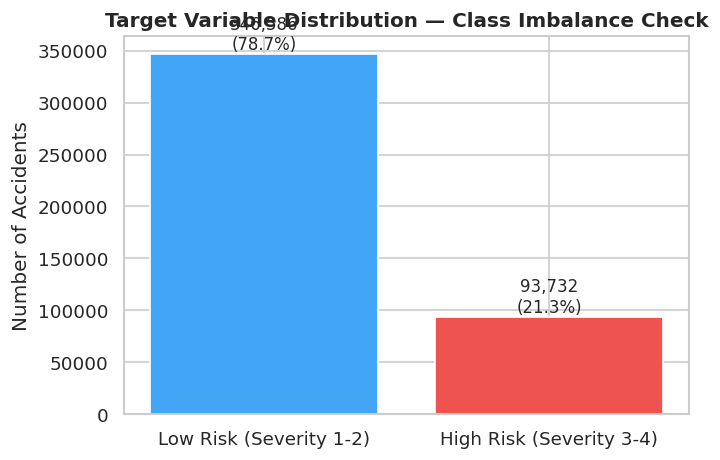

Saved: figures/ml/01_target_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

vc = df["HighRisk"].value_counts().sort_index()
bars = ax.bar(
    ["Low Risk (Severity 1-2)", "High Risk (Severity 3-4)"],
    vc.values,
    color=["#42A5F5", "#EF5350"],
    edgecolor="white"
)
ax.set_title("Target Variable Distribution — Class Imbalance Check",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Accidents")

# Annotate each bar with count and percentage
for bar, val in zip(bars, vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.savefig("figures/ml/01_target_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: figures/ml/01_target_distribution.png")

## Block 8 — Feature Engineering & Encoding

Feature selection is based on Phase 2 findings AND both external datasets:

**From main dataset (Phase 2 EDA & Hypothesis Tests):**
- `Hour / TimeOfDay` → H3: Evening has highest high-risk rate (22.8%)
- `IsRushHour` → H4: Rush hours = 32.7% of all accidents
- `Junction / Traffic_Signal` → Panel 2: Junction raises risk to 29%
- `Visibility / Temperature` → H2: Snow and Rain significantly increase severity

**From US Census enrichment:**
- `accidents_per_100k` → normalizes state-level risk by population

**From NOAA enrichment:**
- `Normal_Precip_in` → monthly precipitation baseline
- `Normal_Temp_F` → monthly temperature baseline
- `Above_Normal_Precip` → binary flag for high-precipitation months

**Encoding strategy (Week 9 — Categorical Features lecture):**
- Road Boolean columns → integer 0 / 1
- String categoricals → dummy encoding with `drop_first=True`
  *(Week 9: "drop a feature randomly to avoid multicollinearity")*
- Numeric missing values → filled with median

In [10]:
# Continuous numeric features
# Includes both original + enrichment features from Phase 2
numeric_features = [
    "Temperature(F)",       # adverse cold increases risk (Phase 2 H2)
    "Wind_Speed(mph)",      # strong wind increases severity
    "Humidity(%)",          # correlates with visibility (Phase 2 Panel 2)
    "Visibility(mi)",       # low visibility → higher risk
    "Pressure(in)",         # barometric pressure as weather proxy
    "Hour",                 # most predictive temporal feature (Phase 2 EDA)
    "Month",                # seasonal patterns
    "IsWeekend",            # Phase 2 H1 — weekend vs weekday
    "IsRushHour",           # Phase 2 H4 — rush hour proportion
    "accidents_per_100k",   # US Census enrichment — state-level risk
    "Normal_Precip_in",     # NOAA — monthly precipitation baseline
    "Normal_Temp_F",        # NOAA — monthly temperature baseline
    "Above_Normal_Precip"   # NOAA — binary: above average precip month
]

# Boolean road-infrastructure features
# Phase 2 Panel 2 showed junctions and signals significantly affect risk
road_features = [
    "Amenity", "Crossing", "Junction", "No_Exit",
    "Railway", "Station", "Stop", "Traffic_Signal"
]


# Categorical features →
# drop_first=True avoids multicollinearity
categorical_features = ["WeatherCategory", "TimeOfDay"]


numeric_features     = [c for c in numeric_features     if c in df.columns]
road_features        = [c for c in road_features        if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]


feature_cols = numeric_features + road_features + categorical_features
data = df[feature_cols + ["HighRisk"]].copy()


for col in road_features:
    data[col] = data[col].astype(str).str.upper().map(
        {"TRUE": 1, "FALSE": 0, "1": 1, "0": 0}
    ).fillna(0).astype(int)


for col in numeric_features:
    data[col] = data[col].fillna(data[col].median())

# Dummy encoding: one binary column per category value
# drop_first=True drops one column per group to avoid perfect multicollinearity
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)


data.dropna(inplace=True)

print(f"ML dataset shape     : {data.shape}")
print(f"Number of features   : {data.shape[1] - 1}")
print(f"Missing values left  : {data.isnull().sum().sum()}")
print(f"\nAll features ({data.shape[1]-1} total):")
for i, col in enumerate(data.drop(columns=["HighRisk"]).columns, 1):
    print(f"  {i:2}. {col}")

ML dataset shape     : (440318, 32)
Number of features   : 31
Missing values left  : 0

All features (31 total):
   1. Temperature(F)
   2. Wind_Speed(mph)
   3. Humidity(%)
   4. Visibility(mi)
   5. Pressure(in)
   6. Hour
   7. Month
   8. IsWeekend
   9. IsRushHour
  10. accidents_per_100k
  11. Normal_Precip_in
  12. Normal_Temp_F
  13. Above_Normal_Precip
  14. Amenity
  15. Crossing
  16. Junction
  17. No_Exit
  18. Railway
  19. Station
  20. Stop
  21. Traffic_Signal
  22. WeatherCategory_Cloudy
  23. WeatherCategory_Fog
  24. WeatherCategory_Other
  25. WeatherCategory_Rain
  26. WeatherCategory_Snow
  27. WeatherCategory_Storm
  28. WeatherCategory_Wind
  29. TimeOfDay_Evening
  30. TimeOfDay_Morning
  31. TimeOfDay_Night


## Block 9 — Majority Class Baseline

From the Week 8 lecture (Baseline Models):
*"For classification — Majority class baseline: every data point is classified
as the class most frequently represented in the training data."*

This sets the minimum performance bar that all models must exceed to be useful.

In [11]:
# Majority class baseline — always predict the most common class (Low Risk = 0)
majority_class = data["HighRisk"].mode()[0]
y_baseline     = np.full(len(data), majority_class)

baseline_acc = accuracy_score(data["HighRisk"], y_baseline)
baseline_f1  = f1_score(data["HighRisk"], y_baseline, zero_division=0)

print("=" * 50)
print("  Majority Class Baseline (Week 8 lecture)")
print("=" * 50)
print(f"  Always predicts class  : {majority_class} (Low Risk)")
print(f"  Baseline Accuracy      : {baseline_acc:.4f}")
print(f"  Baseline F1-score      : {baseline_f1:.4f}")
print()
print("  → All models must score higher than this to be useful.")

# Save for Notebook B comparison table
baseline_results = {"accuracy": round(baseline_acc, 4), "f1": round(baseline_f1, 4)}

  Majority Class Baseline (Week 8 lecture)
  Always predicts class  : 0 (Low Risk)
  Baseline Accuracy      : 0.7871
  Baseline F1-score      : 0.0000

  → All models must score higher than this to be useful.


## Block 10 — Train / Test Split & Feature Scaling


- 80% training set, 20% test set
- `stratify=y` ensures both sets share the exact same HighRisk class ratio
- *"The one commandment of machine learning: do not train on test data"*

Scaling
- Scale to unit variance: makes the features vary on the same scale."
- `StandardScaler` fitted only on training data, then applied to test
- Fitting on the full dataset = data leakage
- Tree-based models (Random Forest, Gradient Boosting) do NOT need scaling

In [12]:
X = data.drop(columns=["HighRisk"])
y = data["HighRisk"]

# Stratified split — preserves 21%/79% class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set         : {X_train.shape[0]:,} samples")
print(f"Test set             : {X_test.shape[0]:,} samples")
print(f"Train HighRisk ratio : {y_train.mean():.3f}")
print(f"Test  HighRisk ratio : {y_test.mean():.3f}")

# StandardScaler — used ONLY for Logistic Regression
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features]  = scaler.transform(X_test[numeric_features])

print("\nSplit and scaling complete — no data leakage!")

Training set         : 352,254 samples
Test set             : 88,064 samples
Train HighRisk ratio : 0.213
Test  HighRisk ratio : 0.213

Split and scaling complete — no data leakage!


## Block 11 — Save All Data to Disk

Save all arrays and objects so that Notebooks B and C
can load them directly without re-running this notebook.

In [13]:
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

# Then save to Drive instead of local
import os
save_dir = "/content/drive/MyDrive/DSA210_ml_data"
os.makedirs(save_dir, exist_ok=True)

X_train.to_csv(f"{save_dir}/X_train.csv", index=False)
X_test.to_csv(f"{save_dir}/X_test.csv", index=False)
X_train_scaled.to_csv(f"{save_dir}/X_train_scaled.csv", index=False)
X_test_scaled.to_csv(f"{save_dir}/X_test_scaled.csv", index=False)
y_train.to_csv(f"{save_dir}/y_train.csv", index=False)
y_test.to_csv(f"{save_dir}/y_test.csv", index=False)
joblib.dump(scaler, f"{save_dir}/scaler.pkl")

import json
with open(f"{save_dir}/numeric_features.json", "w") as f:
    json.dump(numeric_features, f)
with open(f"{save_dir}/baseline.json", "w") as f:
    json.dump(baseline_results, f)

print("Saved to Google Drive!")

Mounted at /content/drive
Saved to Google Drive!


## Notebook A Complete



### Files Saved

| File | Contents |
|------|----------|
| `ml_data/X_train.csv` | Training features — unscaled (for RF & GB) |
| `ml_data/X_test.csv` | Test features — unscaled |
| `ml_data/X_train_scaled.csv` | Training features — scaled (for Logistic Regression) |
| `ml_data/X_test_scaled.csv` | Test features — scaled |
| `ml_data/y_train.csv` | Training labels |
| `ml_data/y_test.csv` | Test labels |
| `ml_data/scaler.pkl` | Fitted StandardScaler object |
| `ml_data/numeric_features.json` | List of numeric feature names |
| `ml_data/baseline.json` | Majority class baseline scores |
| `figures/ml/01_target_distribution.png` | Class imbalance chart |

### Features Used (from all 3 data sources)

| Source | Features |
|--------|----------|
| US Accidents dataset | Temperature, Visibility, Humidity, Pressure, Wind Speed, Hour, Month, IsWeekend, IsRushHour, all road features, WeatherCategory, TimeOfDay |
| US Census Bureau 2020 | `accidents_per_100k` |
| NOAA Climate Normals 1991–2020 | `Normal_Precip_in`, `Normal_Temp_F`, `Above_Normal_Precip` |

In [14]:
from google.colab import files
files.download("figures/ml/01_target_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>